# Crime Safety Detection — Exploratory Data Analysis


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
data=pd.read_csv("Crime Safety Detection.zip")
print(data)

       id        date      time    crime_type          city state  \
0       1  2022-09-09  18:58:57      Homicide  Philadelphia    PA   
1       2  2022-07-10  12:10:59       Assault       Phoenix    AZ   
2       3  2024-12-31  09:26:12      Burglary   San Antonio    TX   
3       4  2024-04-12  23:17:28     Vandalism  Philadelphia    PA   
4       5  2023-07-19  04:49:39         Fraud   San Antonio    TX   
..    ...         ...       ...           ...           ...   ...   
995   996  2023-02-23  07:24:57       Assault      New York    NY   
996   997  2024-10-15  18:10:35  Drug Offense      San Jose    CA   
997   998  2024-02-08  04:00:11       Assault       Houston    TX   
998   999  2023-01-18  16:52:36      Homicide       Chicago    IL   
999  1000  2022-07-19  01:28:45      Homicide   Los Angeles    CA   

    location_description  victim_age victim_gender victim_race  
0          9916 Broadway          34          Male       Other  
1            6853 Oak St          13     

In [3]:
data.dtypes

id                       int64
date                    object
time                    object
crime_type              object
city                    object
state                   object
location_description    object
victim_age               int64
victim_gender           object
victim_race             object
dtype: object

In [37]:
data.columns

Index(['id', 'date', 'time', 'crime_type', 'city', 'state',
       'location_description', 'victim_age', 'victim_gender', 'victim_race',
       'hour', 'time_period', 'age_group', 'age_bracket'],
      dtype='object')

In [5]:
data.head()

,id,date,time,crime_type,city,state,location_description,victim_age,victim_gender,victim_race
0,1,2022-09-09,18:58:57,Homicide,Philadelphia,PA,9916 Broadway,34,Male,Other
1,2,2022-07-10,12:10:59,Assault,Phoenix,AZ,6853 Oak St,13,Female,Black
2,3,2024-12-31,09:26:12,Burglary,San Antonio,TX,3760 Maple Ave,23,Male,Asian
3,4,2024-04-12,23:17:28,Vandalism,Philadelphia,PA,6781 Main St,36,Other,Asian
4,5,2023-07-19,04:49:39,Fraud,San Antonio,TX,3239 Broadway,26,Other,Other


In [6]:
print(data[data["victim_age"]>30])

       id        date      time    crime_type          city state  \
0       1  2022-09-09  18:58:57      Homicide  Philadelphia    PA   
3       4  2024-04-12  23:17:28     Vandalism  Philadelphia    PA   
5       6  2021-09-30  03:17:56  Drug Offense       Chicago    IL   
6       7  2024-11-22  08:41:48      Homicide  Philadelphia    PA   
7       8  2023-12-09  08:10:36  Drug Offense       Houston    TX   
..    ...         ...       ...           ...           ...   ...   
993   994  2021-04-16  08:06:42      Burglary      San Jose    CA   
994   995  2025-05-15  13:34:13  Drug Offense     San Diego    CA   
995   996  2023-02-23  07:24:57       Assault      New York    NY   
997   998  2024-02-08  04:00:11       Assault       Houston    TX   
999  1000  2022-07-19  01:28:45      Homicide   Los Angeles    CA   

    location_description  victim_age victim_gender victim_race  
0          9916 Broadway          34          Male       Other  
3           6781 Main St          36     

In [7]:
data.drop_duplicates()

,id,date,time,crime_type,city,state,location_description,victim_age,victim_gender,victim_race
0,1,2022-09-09,18:58:57,Homicide,Philadelphia,PA,9916 Broadway,34,Male,Other
1,2,2022-07-10,12:10:59,Assault,Phoenix,AZ,6853 Oak St,13,Female,Black
2,3,2024-12-31,09:26:12,Burglary,San Antonio,TX,3760 Maple Ave,23,Male,Asian
3,4,2024-04-12,23:17:28,Vandalism,Philadelphia,PA,6781 Main St,36,Other,Asian
4,5,2023-07-19,04:49:39,Fraud,San Antonio,TX,3239 Broadway,26,Other,Other
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-02-23,07:24:57,Assault,New York,NY,2793 Oak St,72,Female,Asian
996,997,2024-10-15,18:10:35,Drug Offense,San Jose,CA,2798 Elm St,26,Male,Other
997,998,2024-02-08,04:00:11,Assault,Houston,TX,8950 Pine St,34,Non-binary,Hispanic
998,999,2023-01-18,16:52:36,Homicide,Chicago,IL,4673 Oak St,16,Other,Hispanic


In [8]:
data.isnull().sum()

id                      0
date                    0
time                    0
crime_type              0
city                    0
state                   0
location_description    0
victim_age              0
victim_gender           0
victim_race             0
dtype: int64

## Age and Time-Based Crime Victimization Analysis

In [9]:

data["hour"] = pd.to_datetime(data["time"], format="%H:%M:%S").dt.hour

# Time period 
def time_period(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

data["time_period"] = data["hour"].apply(time_period)

# Age group 
data["age_group"] = data["victim_age"].apply(lambda x: "Above 30" if x > 30 else "30 or Below")


result = data.groupby(["crime_type", "time_period", "age_group"]).size()
print(result)

crime_type  time_period  age_group  
Arson       Afternoon    30 or Below     5
                         Above 30       15
            Evening      30 or Below     7
                         Above 30       25
            Morning      30 or Below     5
                                        ..
Vandalism   Evening      Above 30       16
            Morning      30 or Below     3
                         Above 30       18
            Night        30 or Below     3
                         Above 30       26
Length: 80, dtype: int64


In [11]:
def age_bracket(age):
    if age <= 30:
        return "30 or Below"
    elif age <= 40:
        return "31-40"
    elif age <= 50:
        return "41-50"
    elif age <= 60:
        return "51-60"
    else:
        return "60+"

data["age_bracket"] = data["victim_age"].apply(age_bracket)

# Har bracket mein kitne cases hain
print(data["age_bracket"].value_counts())

age_bracket
60+            405
30 or Below    230
51-60          126
41-50          122
31-40          117
Name: count, dtype: int64


In [12]:
result = data.groupby(["time_period", "age_bracket"]).size()
print(result)

time_period  age_bracket
Afternoon    30 or Below     62
             31-40           37
             41-50           21
             51-60           25
             60+            100
Evening      30 or Below     58
             31-40           25
             41-50           38
             51-60           30
             60+            108
Morning      30 or Below     53
             31-40           26
             41-50           26
             51-60           26
             60+            110
Night        30 or Below     57
             31-40           29
             41-50           37
             51-60           45
             60+             87
dtype: int64


In [13]:
data.describe()

,id,victim_age,hour
count,1000.000000,1000.000000,1000.000000
mean,500.500000,52.201000,11.513000
std,288.819436,22.913831,6.988037
min,1.000000,12.000000,0.000000
25%,250.750000,33.000000,5.000000
50%,500.500000,53.000000,12.000000
75%,750.250000,72.000000,18.000000
max,1000.000000,90.000000,23.000000


In [14]:
evening_night = data[data["time_period"].isin(["Evening", "Night"])]
print("Mean (Evening/Night):", evening_night["victim_age"].mean())
print("Median (Evening/Night):", evening_night["victim_age"].median())
print("Mode (Evening/Night):", evening_night["victim_age"].mode()[0])

Mean (Evening/Night): 51.92217898832685
Median (Evening/Night): 52.0
Mode (Evening/Night): 52


In [15]:
print(data["crime_type"].value_counts())

crime_type
Domestic Violence    121
Burglary             121
Robbery              101
Homicide             101
Arson                 98
Assault               97
Vandalism             94
Fraud                 89
Drug Offense          89
Theft                 89
Name: count, dtype: int64


In [16]:
top_crimes = data[data["crime_type"].isin(["Domestic Violence", "Burglary"])]

result = top_crimes.groupby(["crime_type", "time_period", "age_bracket"]).size()
print(result)

crime_type         time_period  age_bracket
Burglary           Afternoon    30 or Below     9
                                31-40           1
                                41-50           4
                                51-60           1
                                60+            12
                   Evening      30 or Below    12
                                31-40           3
                                41-50           6
                                51-60           4
                                60+            12
                   Morning      30 or Below     5
                                31-40           4
                                41-50           3
                                60+            20
                   Night        30 or Below     3
                                31-40           4
                                41-50           5
                                51-60           7
                                60+             6
Domest

In [17]:
dv = data[data["crime_type"] == "Domestic Violence"]
print(dv.groupby(["time_period", "age_bracket"]).size())

time_period  age_bracket
Afternoon    30 or Below     7
             31-40           6
             41-50           1
             51-60           4
             60+            14
Evening      30 or Below     7
             31-40           4
             41-50           2
             51-60           5
             60+            14
Morning      30 or Below     8
             31-40           4
             41-50           3
             51-60           4
             60+            13
Night        30 or Below     8
             31-40           4
             41-50           3
             51-60           4
             60+             6
dtype: int64


In [38]:

y = data["crime_type"]

X = data[["city", "age_bracket", "time_period", "victim_gender", "victim_race", "state"]]
X = pd.get_dummies(X, columns=["city", "age_bracket", "time_period", "victim_gender", "victim_race", "state"], drop_first=True)

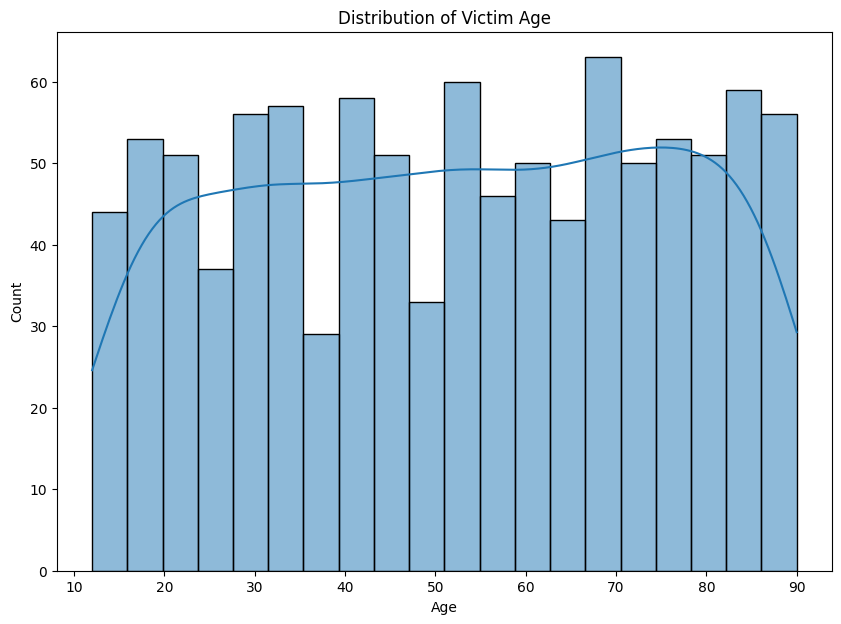

In [39]:
plt.figure(figsize=(10,7))
sns.histplot(data["victim_age"], bins=20, kde=True)
plt.title("Distribution of Victim Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

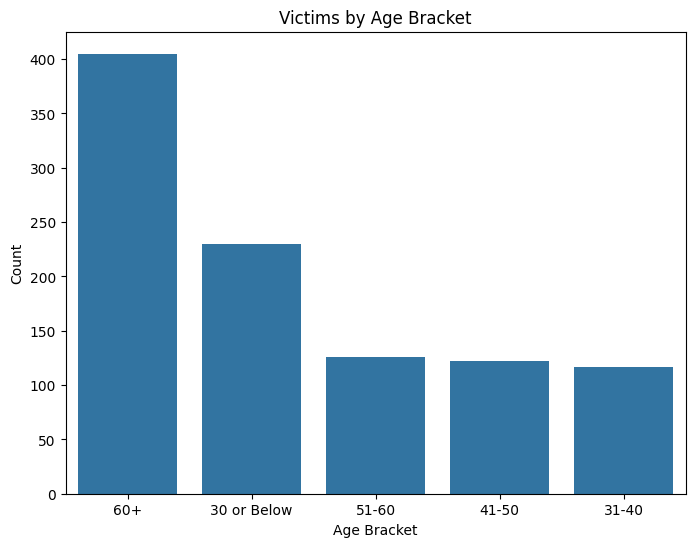

In [19]:
plt.figure(figsize=(8,6))
sns.countplot(data=data, x="age_bracket", order=data["age_bracket"].value_counts().index)
plt.title("Victims by Age Bracket")
plt.xlabel("Age Bracket")
plt.ylabel("Count")
plt.show()

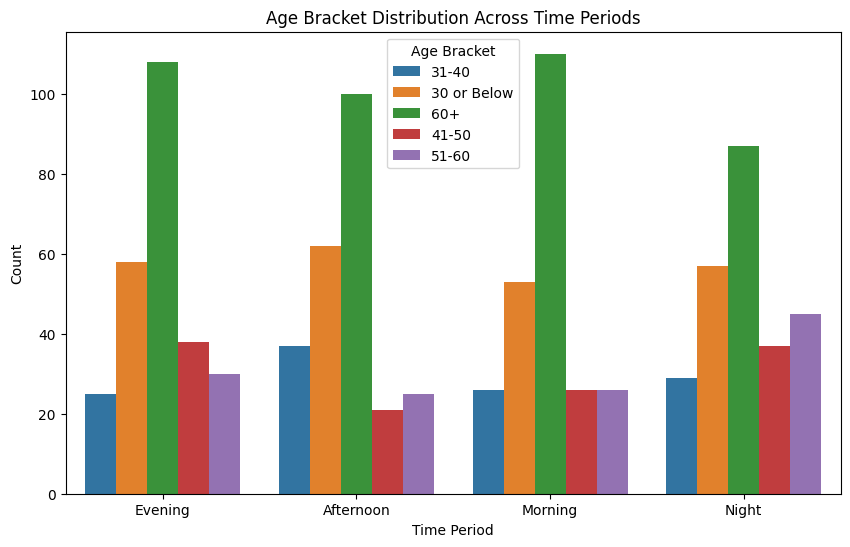

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, x="time_period", hue="age_bracket")
plt.title("Age Bracket Distribution Across Time Periods")
plt.xlabel("Time Period")
plt.ylabel("Count")
plt.legend(title="Age Bracket")
plt.show()

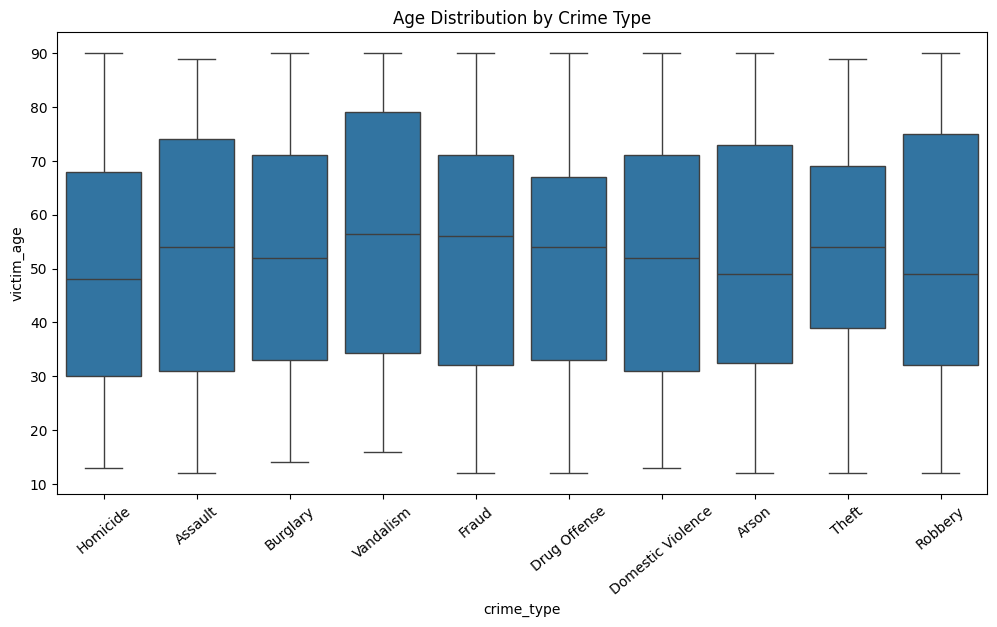

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x="crime_type", y="victim_age")
plt.xticks(rotation=40)
plt.title("Age Distribution by Crime Type")
plt.show()

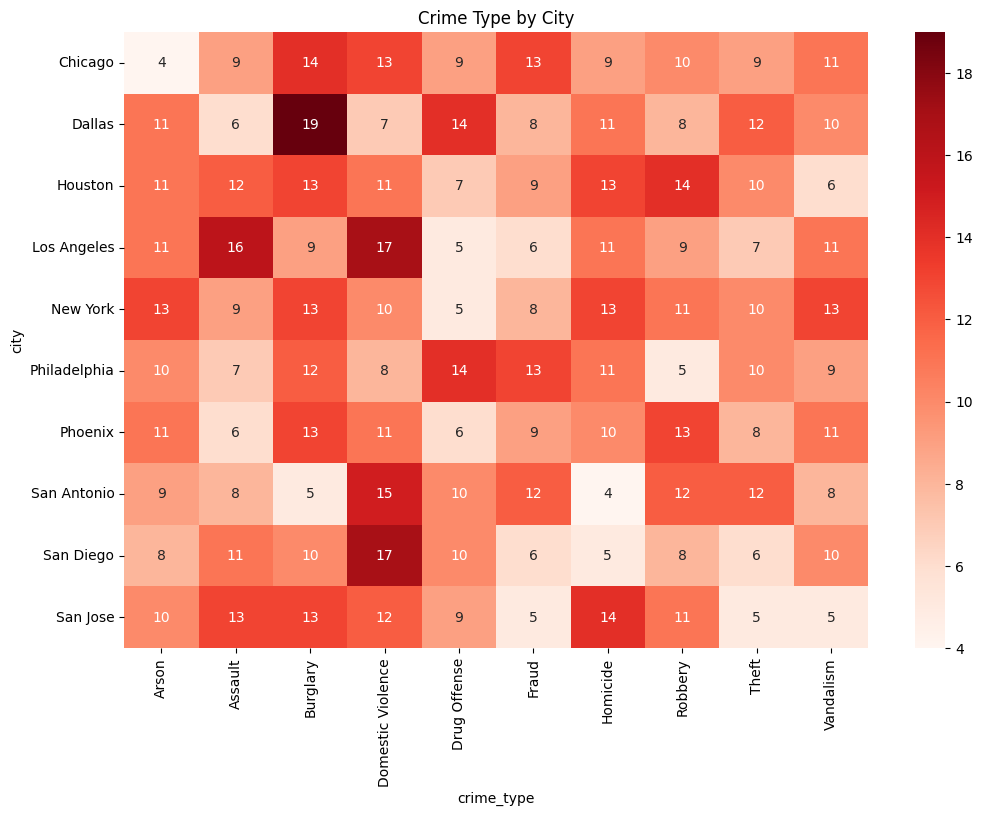

In [22]:
city_crime = pd.crosstab(data["city"], data["crime_type"])
plt.figure(figsize=(12,8))
sns.heatmap(city_crime, annot=True, fmt="d", cmap="Reds")
plt.title("Crime Type by City")
plt.show()

In [33]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ("model", model)
])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [35]:
y_pred = pipeline.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.125
                   precision    recall  f1-score   support

            Arson       0.17      0.18      0.17        22
          Assault       0.08      0.05      0.06        21
         Burglary       0.15      0.17      0.16        23
Domestic Violence       0.14      0.09      0.11        22
     Drug Offense       0.00      0.00      0.00        18
            Fraud       0.09      0.12      0.11        16
         Homicide       0.17      0.32      0.22        19
          Robbery       0.09      0.10      0.09        21
            Theft       0.06      0.05      0.06        19
        Vandalism       0.19      0.16      0.17        19

         accuracy                           0.12       200
        macro avg       0.11      0.12      0.11       200
     weighted avg       0.12      0.12      0.12       200



In [36]:
pd.crosstab(data["city"], data["crime_type"])

crime_type,Arson,Assault,Burglary,Domestic Violence,Drug Offense,Fraud,Homicide,Robbery,Theft,Vandalism
city,,,,,,,,,,
Chicago,4,9,14,13,9,13,9,10,9,11
Dallas,11,6,19,7,14,8,11,8,12,10
Houston,11,12,13,11,7,9,13,14,10,6
Los Angeles,11,16,9,17,5,6,11,9,7,11
New York,13,9,13,10,5,8,13,11,10,13
Philadelphia,10,7,12,8,14,13,11,5,10,9
Phoenix,11,6,13,11,6,9,10,13,8,11
San Antonio,9,8,5,15,10,12,4,12,12,8
San Diego,8,11,10,17,10,6,5,8,6,10


In [41]:
y = data["crime_type"]

X = data[["city", "age_bracket", "time_period", "victim_gender", "victim_race", "state"]]
X = pd.get_dummies(X, columns=["city", "age_bracket", "time_period", "victim_gender", "victim_race", "state"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.115
